<img src="./logo_UTN.svg" align="right" width="150" />

# Tarea Semanal 8

*Alumno: Lapilli Cañedo, Mariano Adrian*

In [2]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
import control as ct
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys
from pytc2.sistemas_lineales import pretty_print_lti
from pytc2.general import print_latex, a_equal_b_latex_s
from pytc2.cuadripolos import calc_MAI_ztransf_ij_mn
from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
import sympy as sp
import control.matlab as ctl

### Item 1

Sea la función Inmitancia

 $$F(s) = \frac{ s^{4} + 4s^{2} +3 }{s (s^{2} + 2)}$$

Se pide hallar la topología circuital y los valores de los componentes

a) Síntesis de $Z(s)$  mediante el método de Foster en su versión serie

b) Síntesis de $Y(s)$ mediante el método de Foster en su versión derivación

c) Síntesis de $Z(s)$ mediante el método de Cauer remoción en infinito 

d) Síntesis de $Z(s)$ mediante el método de Cauer remoción en DC  

e) Simular $Z(s)$ en LTSpice , observando los cambios de fase y la ley de variación ( pendiente ) de la impedancia total de la red.


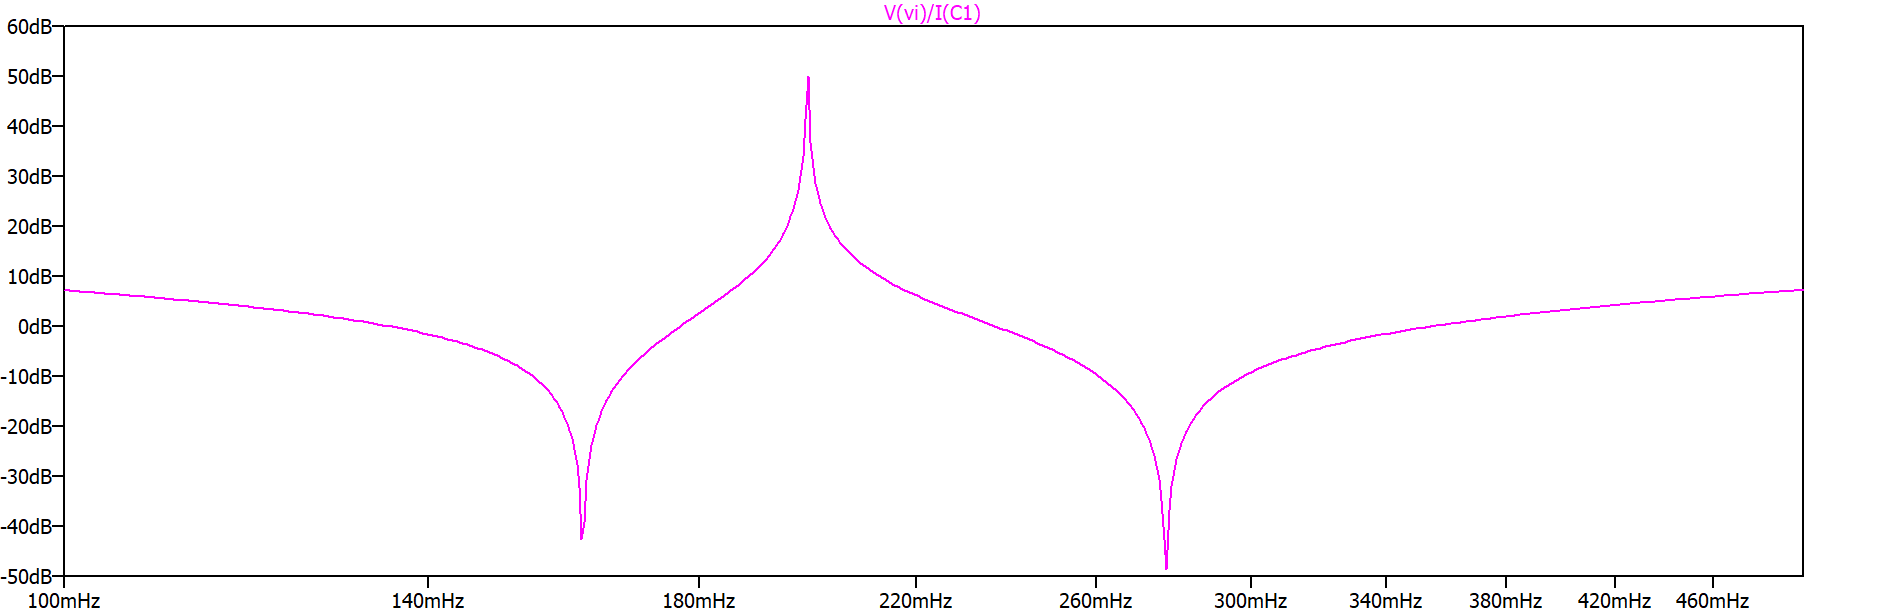


### Item 2
 
Sea la siguiente red , pensandolo como una inmitancia $F_{12}$

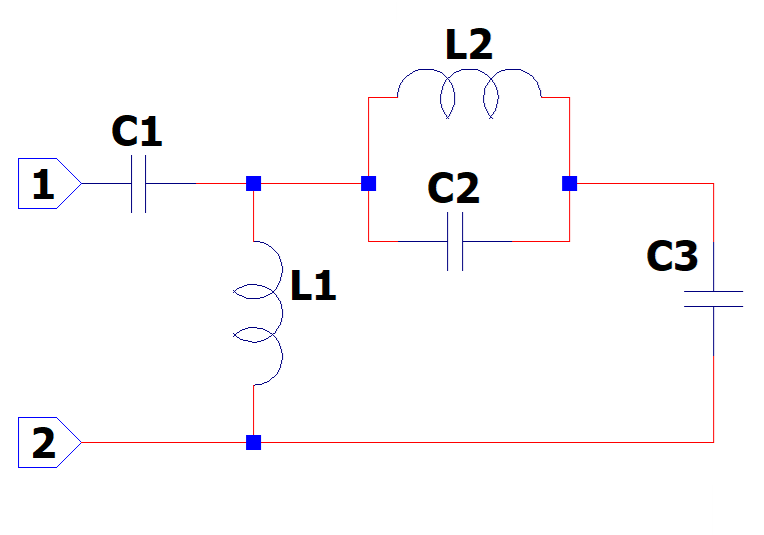

a) Hallar el valor de los componentes sabiendo que satisface la función admitancia propuesta

$$Y(s) = \frac{ s^{5} + 18s^{3} + 48 s }{ 6s^{4} + 42s^{2} + 48 }$$


### Item 3

Encuentre el valor de los elementos que integran el siguiente circuito y que satisface la función impedancia propuesta:

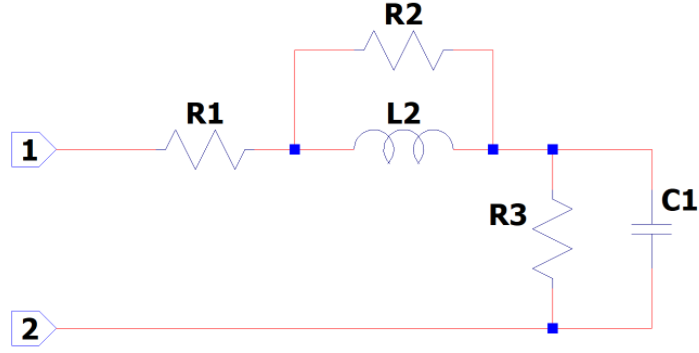

$$Z(s) = \frac{ s^{2} + 6s + 8 }{ s^{2} + 6s + 5 }$$

### Bonus

. 💎 Implementar en Python el punto 1 verificando los resultados usando las funciones de pytc2 : 
dibujar_foster_serie ; dibujar_foster_derivacion ; dibujar_cauer_LC; 

. 🎓 Simulación circuital del punto 2. Medir la admitancia y explicar comportamiento en DC 

## Item 1

Tenemos la siguiente función de inmitancia:

$$F(s) = \frac{ s^{4} + 4s^{2} +3 }{s^{3} + 2s}$$

Vamos a buscar los polos y ceros de esta función:

array([-0.+1.41421356j,  0.-1.41421356j,  0.+0.j        ])

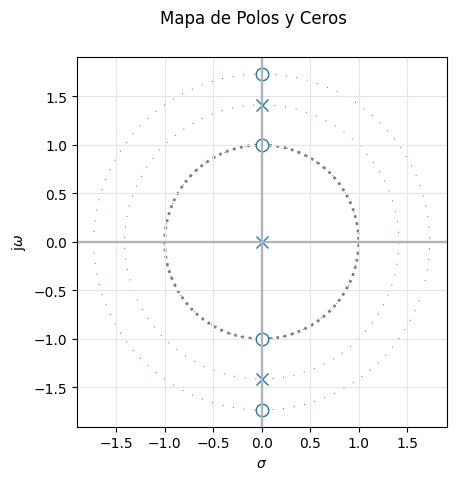

In [3]:
# busco polos y ceros de la función

num = [1 , 0, 4, 0, 3]
den = [1, 0, 2, 0]

H = sig.TransferFunction(num, den)

pzmap(H)

np.roots(den)

Los polos estan en $+ \sqrt{2}$ y $- \sqrt{2}$ (además de en 0)

La serie de Foster se describe como una expresión en fracciones simples:

$$Z(s) = \frac{K_0}{s} +  s \ K_{\infty} + \sum_{i = 0}^{N} \frac{2 \ s \ K_i }{s^{2} + \omega_{i}^{2} }$$

Donde K son los valores de residuos en la vecindad de las singularidades

Residuo $K_0$

$$K_0 = \lim_{s \to 0} s \ \frac{ s^{4} + 4s^{2} +3 }{s (s^{2} + 2)} = \frac{3}{2}$$

Residuo $K_{\infty}$:

$$K_{\infty} = \lim_{s \to \infty} \frac{1}{s} \ \frac{ s^{4} + 4s^{2} +3 }{s (s^{2} + 2)} = 1$$

Residuo $K_{\sqrt{2}}$:

$$ 2 K_{\sqrt{2}} = \lim_{s \to \sqrt{2}} \frac{1}{s} \ \frac{ s^{4} + 4s^{2} +3 }{s (s^{2} + 2)} = \frac{15}{8}$$

Queda como resultado:

$$Z(s) = \frac{3}{2 \ s} +  s  + \frac{ s \ \frac{15}{8} }{s^{2} + 2 }$$

Para sintetizar la red de esta forma primero tomamos como ejemplo la red Foster $Serie$ que vimos en clase:

**NOTA: los gráficos están hechos en python (los archivos los adjunto en la entrega)**

<img src="./Foster Serie.png" width="1000" />

Donde ya la red nos determina los valores de los componentes:

$$ C_0 = \frac{1}{K_0} = \frac{2}{3} $$

$$ L_0 = K_{\infty} = 1 $$

$$ L_1 = \frac{2 K_1}{ \omega_1 ^2} = \frac{15}{16} $$

$$ C_1 = \frac{1}{2 K_1} = \frac{8}{15} $$

b) Para este inciso vamos a recurrir también a la forma canónica de Foster en su asociación $Paralelo$

<img src="./Foster Paralelo.png" width="1000" />

Quedando los valores de componentes de la siguiente manera:

$$ L_0 = \frac{1}{K_0} = \frac{2}{3} $$

$$ C_0 = K_{\infty} = 1 $$

$$ C_1 = \frac{2 K_1}{ \omega_1 ^2} = \frac{15}{16} $$

$$ L_1 = \frac{1}{2 K_1} = \frac{8}{15} $$

c) Como estamos removiendo en infinito, podemos decir que la red tiene esta forma:

<img src="./Cauer Infinito.png" width="1000" />

Para esto vamos a utilizar el algoritmo de Cauer por división de Polinomios, adjunto desarrollo hecho en el pizarrón:

<img src="./res1.jpg" width="1000" />

d) Lo mismo para Cauer con remoción en DC:

<img src="./Cauer DC.png" width="1000" />

Esta vez, vamos a resolverlo removiendo y buscando residuos en cero, adjunto resolución en el pizarrón hecha por mí:

<img src="./res2.jpg" width="1000" />